In [1]:
!pip install xgboost lightgbm catboost scikit-learn pandas matplotlib seaborn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


Loading /content/Final_Labeled_Pollution_Dataset.csv...

Training on 14 features: ['dist_road', 'dist_industry', 'dist_dump', 'dist_farmland', 'co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'Temperature', 'Humidity', 'Wind Speed', 'Wind Direction']

🏟️ Welcome to the Model Showdown! Training 12 models...

🏆 LEADERBOARD (Cross-Validation Accuracy):
---------------------------------------------
1. LightGBM                  | 0.9994
2. Gradient Boosting (Sklearn) | 0.9991
3. Decision Tree             | 0.9987
4. CatBoost                  | 0.9987
5. XGBoost                   | 0.9985
6. Random Forest             | 0.9979
7. Neural Network (MLP)      | 0.9902
8. K-Nearest Neighbors       | 0.9750
9. Support Vector Machine    | 0.9663
10. AdaBoost                  | 0.9644
11. Logistic Regression       | 0.9631
12. Naive Bayes               | 0.9406

🥇 The overall winner is: LightGBM!

=== Final Test Evaluation (LightGBM) ===
Accuracy:  0.9970
Precision: 0.9970
Recall:    0.9970
F1-Score:  0.997

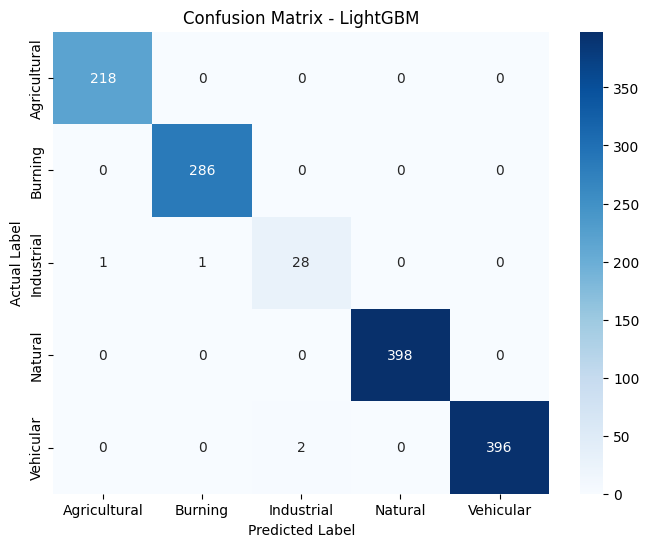

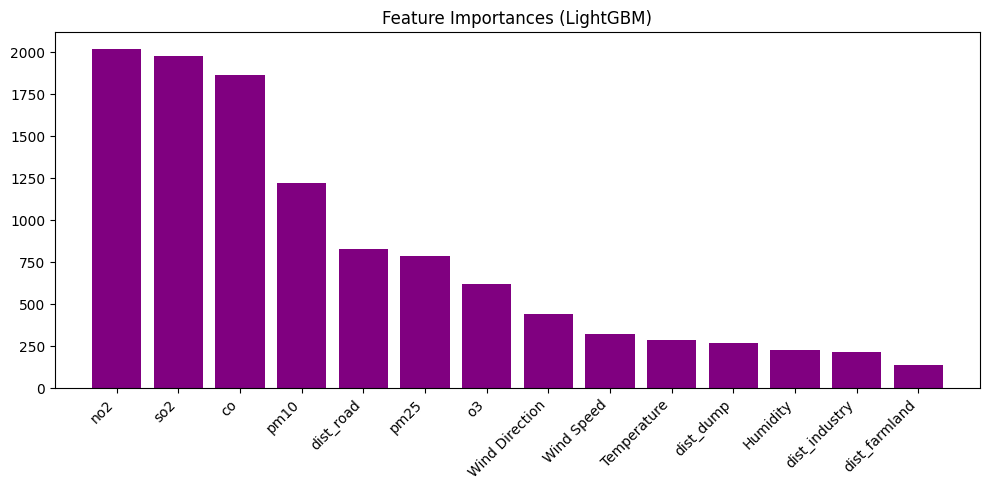

✅ Best model, label encoder, and standard scaler successfully saved to the 'models' folder!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore') # Hides annoying warning messages

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Import ALL the models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ==========================================
# 1. Load and Prepare the Dataset
# ==========================================
# IMPORTANT: Change this to your exact filename in Colab
file_name = '/content/Final_Labeled_Pollution_Dataset.csv'
print(f"Loading {file_name}...\n")
df = pd.read_csv(file_name).dropna()

# Automatically grab all numeric columns to avoid name mismatch errors
features = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove columns that shouldn't be trained on (if they exist)
columns_to_exclude = ['latitude', 'longitude', 'timestamp', 'id', 'Unnamed: 0']
features = [f for f in features if f not in columns_to_exclude]

print(f"Training on {len(features)} features: {features}\n")

X = df[features]
y_raw = df['pollution_source']

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# Scale features (CRITICAL for SVM, KNN, and Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. Train-Test Split (80/20)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)

# ==========================================
# 3. Define the Massive Model Dictionary
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting (Sklearn)": GradientBoostingClassifier(random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42) # verbose=0 stops it from printing hundreds of lines
}

# ==========================================
# 4. The Great Model Shootout (Cross-Validation)
# ==========================================
print("🏟️ Welcome to the Model Showdown! Training 12 models...\n")

results = []
best_model = None
best_score = 0
best_name = ""

for name, model in models.items():
    # Use 5-fold cross-validation on the training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    mean_score = cv_scores.mean()
    results.append((name, mean_score))

    if mean_score > best_score:
        best_score = mean_score
        best_name = name
        best_model = model

# Sort and print leaderboard
results.sort(key=lambda x: x[1], reverse=True)
print("🏆 LEADERBOARD (Cross-Validation Accuracy):")
print("-" * 45)
for rank, (name, score) in enumerate(results, 1):
    print(f"{rank}. {name:<25} | {score:.4f}")

print(f"\n🥇 The overall winner is: {best_name}!")

# ==========================================
# 5. Final Evaluation on Unseen Test Data
# ==========================================
print(f"\n=== Final Test Evaluation ({best_name}) ===")
# Train the best model on the full training set
best_model.fit(X_train, y_train)

# Predict on the test set
y_pred = best_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}\n")

# ==========================================
# 6. Visualizations (Deliverables)
# ==========================================
# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot 2: Feature Importance (If the winning model supports it)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(10, 5))
    plt.title(f"Feature Importances ({best_name})")
    plt.bar(range(X.shape[1]), importances[indices], align="center", color='purple')
    plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45, ha='right')
    plt.xlim([-1, X.shape[1]])
    plt.tight_layout()
    plt.show()
else:
    print(f"Note: {best_name} does not natively support feature importance charting.")

# ==========================================
# 7. Export the Model & Scaler
# ==========================================
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_pollution_model.joblib')
joblib.dump(label_encoder, 'models/label_encoder.joblib')
joblib.dump(scaler, 'models/feature_scaler.joblib') # MUST save the scaler too!
print("✅ Best model, label encoder, and standard scaler successfully saved to the 'models' folder!")